In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look nicer
plt.style.use('default')

In [3]:
# load dataset
file_path = "../data/raw/i80_trajectories_NGSIM.csv"

df = pd.read_csv(file_path)

df.head()

C:\Users\adama\AppData\Local\Temp\ipykernel_27692\34955442.py:4: DtypeWarning: Columns (0: Local_Y, 1: Space_Headway) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


,Vehicle_ID,Frame_ID,Total_Frames,Global_Time,Local_X,Local_Y,Global_X,Global_Y,v_length,v_Width,...,D_Zone,Int_ID,Section_ID,Direction,Movement,Preceding,Following,Space_Headway,Time_Headway,Location
0,2071,8323,379,1113438397200,7.224,0.0,6042842.456,2133039.613,12.3,6.8,...,NaN,NaN,NaN,NaN,NaN,"2,060",0,146.57,"9,999.99",i-80
1,2071,8324,379,1113438397300,7.239,0.0,6042842.112,2133042.392,12.3,6.8,...,NaN,NaN,NaN,NaN,NaN,"2,060",0,150.25,"9,999.99",i-80
2,1895,6565,"1,958",1113438221400,42.224,0.0,6042877.191,2133043.912,14.8,6.9,...,NaN,NaN,NaN,NaN,NaN,"1,887",0,40.08,"9,999.99",i-80
3,1895,6566,"1,958",1113438221500,42.227,0.0,6042877.124,2133044.458,14.8,6.9,...,NaN,NaN,NaN,NaN,NaN,"1,887",0,41.1,"9,999.99",i-80
4,1895,6567,"1,958",1113438221600,42.230,0.0,6042877.056,2133045.004,14.8,6.9,...,NaN,NaN,NaN,NaN,NaN,"1,887",0,42.16,"9,999.99",i-80


In [4]:
# pick one vehicle
vehicle_id = df['Vehicle_ID'].iloc[0]

vehicle_df = df[df['Vehicle_ID'] == vehicle_id]

vehicle_df.head()

,Vehicle_ID,Frame_ID,Total_Frames,Global_Time,Local_X,Local_Y,Global_X,Global_Y,v_length,v_Width,...,D_Zone,Int_ID,Section_ID,Direction,Movement,Preceding,Following,Space_Headway,Time_Headway,Location
0,2071,8323,379,1113438397200,7.224,0.0,6042842.456,2133039.613,12.3,6.8,...,NaN,NaN,NaN,NaN,NaN,"2,060",0,146.57,"9,999.99",i-80
1,2071,8324,379,1113438397300,7.239,0.0,6042842.112,2133042.392,12.3,6.8,...,NaN,NaN,NaN,NaN,NaN,"2,060",0,150.25,"9,999.99",i-80
5,2071,8325,379,1113438397400,7.254,0.0,6042841.768,2133045.170,12.3,6.8,...,NaN,NaN,NaN,NaN,NaN,"2,060",0,154.07,"9,999.99",i-80
11,2071,8326,379,1113438397500,7.269,0.0,6042841.424,2133047.949,12.3,6.8,...,NaN,NaN,NaN,NaN,NaN,"2,060",0,158.05,"9,999.99",i-80
20,2071,8327,379,1113438397600,7.285,0.0,6042841.080,2133050.728,12.3,6.8,...,NaN,NaN,NaN,NaN,NaN,"2,060",0,162.24,"9,999.99",i-80


In [6]:
# sort by time
vehicle_df = vehicle_df.sort_values(by='Frame_ID')

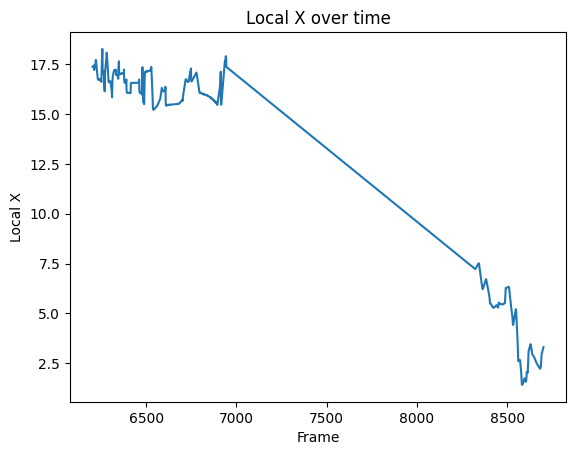

In [7]:
# plot lateral movement
plt.figure()
plt.plot(vehicle_df['Frame_ID'], vehicle_df['Local_X'])
plt.title("Local X over time")
plt.xlabel("Frame")
plt.ylabel("Local X")
plt.show()

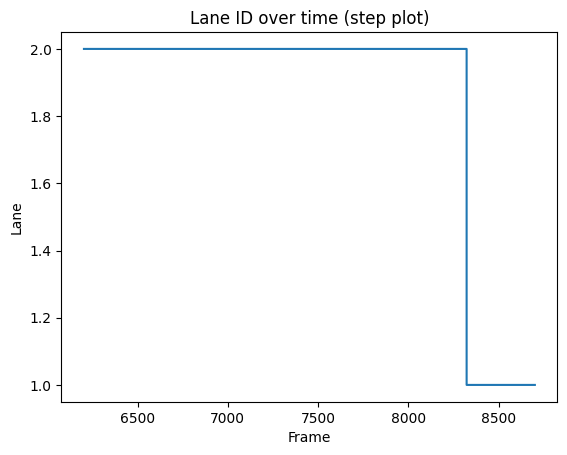

In [11]:
# better lane plot (step-like)
plt.figure()
plt.step(vehicle_df['Frame_ID'], vehicle_df['Lane_ID'], where='post')
plt.title("Lane ID over time (step plot)")
plt.xlabel("Frame")
plt.ylabel("Lane")
plt.show()

In [12]:
# number of vehicles
df['Vehicle_ID'].nunique()

3001

In [13]:
# trajectory length stats
df.groupby('Vehicle_ID').size().describe()

count    3001.000000
mean     1521.621793
std       823.222894
min       204.000000
25%       839.000000
50%      1444.000000
75%      2004.000000
max      5256.000000
dtype: float64

In [16]:
# count stable lane changes
def count_lane_changes(lane_series):
    changes = 0
    prev_lane = lane_series.iloc[0]

    for i in range(1, len(lane_series) - 3):
        curr_lane = lane_series.iloc[i]
        next_lanes = lane_series.iloc[i:i+3]

        # detect stable change
        if curr_lane != prev_lane and all(next_lanes == curr_lane):
            changes += 1
            prev_lane = curr_lane

    return changes


lane_changes_clean = df.sort_values(by=['Vehicle_ID', 'Frame_ID']) \
    .groupby('Vehicle_ID')['Lane_ID'] \
    .apply(count_lane_changes)

lane_changes_clean.describe()

count    3001.000000
mean        1.456848
std         1.478136
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max        10.000000
Name: Lane_ID, dtype: float64

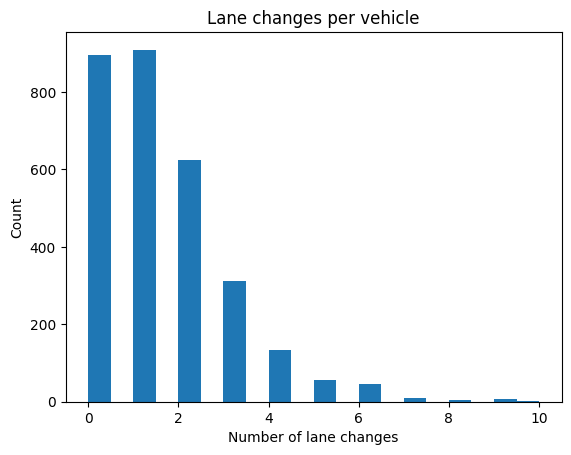

In [22]:
# histogram for lane changes
plt.hist(lane_changes_clean, bins=20)
plt.title("Lane changes per vehicle")
plt.xlabel("Number of lane changes")
plt.ylabel("Count")
plt.show()

In [23]:
# trajectory lengths
trajectory_lengths = df.groupby('Vehicle_ID').size()

# keep vehicles with enough data
valid_vehicles = trajectory_lengths[trajectory_lengths >= 30].index

df_filtered = df[df['Vehicle_ID'].isin(valid_vehicles)]

In [24]:
# new dataset size
df_filtered.shape

(4566387, 25)

In [25]:
# number of vehicles after filtering
df_filtered['Vehicle_ID'].nunique()

3001